Importing the necessary libraries.

In [28]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import joblib
import os

In [50]:
from config import INPUT_DIRS, SAMPLING_RATE, HOP_LENGTH
import config
from feature_extraction.features import remove_background_noise

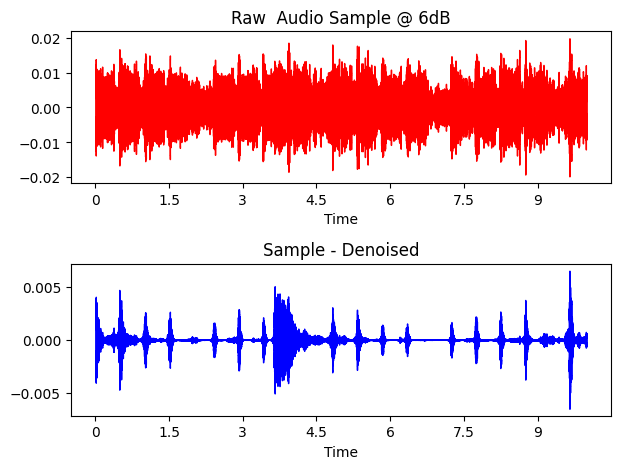

In [17]:
y, sr = librosa.load(r"C:\dev\listen\raw_data\6_dB_slider\slider\id_00\normal\00000000.wav", sr=SAMPLING_RATE)
master_noise = joblib.load(r"C:\dev\listen\scalers\6_dB_slider\slider\id_00\master_noise.pkl")
y_denoised = remove_background_noise(y, sr=sr1, master_noise=master_noise)

fig, ax = plt.subplots(2, 1)
librosa.display.waveshow(y, sr=sr, color='r', ax=ax[0])
ax[0].set_title("Raw  Audio Sample @ 6dB")
librosa.display.waveshow(y_denoised, sr=sr, color='b', ax=ax[1])
ax[1].set_title("Sample - Denoised")

plt.tight_layout()
plt.savefig('6dB Slider Waveform Comparsion.png')
plt.show()

Code block to plot boxgraphs of different audio features.

In [51]:
import seaborn as sns
import joblib
import pandas as pd

# Individual scalar feature extractors (returning floats)
def extract_zcr(y, sr):
    return float(np.mean(librosa.feature.zero_crossing_rate(y=y)))

def extract_spectral_centroid(y, sr):
    return float(np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)))

def extract_amp_variance(y, sr):
    # As discussed, calculating the variance of the RMS time-series frames
    rms_series = librosa.feature.rms(y=y)
    return float(np.var(rms_series)) * 10e6

def extract_machine_mfcc2(y, sr):
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=2)[1]

    return np.mean(mfccs)
    
def build_dataset(normal_dir, abnormal_dir, worker_func, feature_name, master_noise, slice_length=None):
    """Loops through folders to aggregate distinct machine data records."""
    records = []

    # Process Normal Files
    print(f"Processing normal files for {feature_name}...")
    if os.path.exists(normal_dir):
        for file_name in os.listdir(normal_dir)[:slice_length]:
            if file_name.endswith('.wav'):
                file_path = os.path.join(normal_dir, file_name)
                y, sr = librosa.load(file_path, sr=SAMPLING_RATE)
                y = remove_background_noise(y, sr=sr, master_noise=master_noise)
                
                val = worker_func(y, sr)
                records.append({feature_name: val, 'Status': 'Normal'})

    # Process Abnormal Files
    print(f"Processing abnormal files for {feature_name}...")
    if os.path.exists(abnormal_dir):
        for file_name in os.listdir(abnormal_dir)[:slice_length]:
            if file_name.endswith('.wav'):
                # FIX: Corrected path from normal_dir to abnormal_dir
                file_path = os.path.join(abnormal_dir, file_name)
                y, sr = librosa.load(file_path, sr=SAMPLING_RATE)
                y = remove_background_noise(y, sr=sr, master_noise=master_noise)
                
                val = worker_func(y, sr)
                records.append({feature_name: val, 'Status': 'Abnormal'})

    return pd.DataFrame(records)

# Dictionary container to hold independent DataFrames for each asset class
df = {}

# -------------------------------------------------------------------
# Data Aggregation Phase
# -------------------------------------------------------------------

# 1. Normal/Abnormal Slider ZCR
MACHINE_TYPE = r"-6_dB_slider/slider/id_00/"
NORMAL_FOLDER = f"c:/dev/listen/raw_data/{MACHINE_TYPE}normal"
ABNORMAL_FOLDER = f"c:/dev/listen/raw_data/{MACHINE_TYPE}abnormal"
# Check if file exists before loading to prevent crashes
noise_path = f"c:/dev/listen/scalers/{MACHINE_TYPE}master_noise.pkl"
master_noise = joblib.load(noise_path) if os.path.exists(noise_path) else None

df['ZCR'] = build_dataset(NORMAL_FOLDER, ABNORMAL_FOLDER, extract_zcr, 'ZCR', master_noise)


# 2. Normal/Abnormal Pump Spectral Centroid
MACHINE_TYPE = r"-6_dB_pump/pump/id_00/"
NORMAL_FOLDER = f"c:/dev/listen/raw_data/{MACHINE_TYPE}normal"
ABNORMAL_FOLDER = f"c:/dev/listen/raw_data/{MACHINE_TYPE}abnormal"
noise_path = f"c:/dev/listen/scalers/{MACHINE_TYPE}master_noise.pkl"
master_noise = joblib.load(noise_path) if os.path.exists(noise_path) else None

# FIX: Corrected spelling from exctract_spectral_centroid to extract_spectral_centroid
df['Spectral_Centroid'] = build_dataset(NORMAL_FOLDER, ABNORMAL_FOLDER, extract_spectral_centroid, 'Spectral_Centroid', master_noise)


# 3. Normal/Abnormal Fan Amplitude Variance
MACHINE_TYPE = r"-6_dB_fan/fan/id_00/"
NORMAL_FOLDER = f"c:/dev/listen/raw_data/{MACHINE_TYPE}normal"
ABNORMAL_FOLDER = f"c:/dev/listen/raw_data/{MACHINE_TYPE}abnormal"
noise_path = f"c:/dev/listen/scalers/{MACHINE_TYPE}master_noise.pkl"
master_noise = joblib.load(noise_path) if os.path.exists(noise_path) else None

df['Amplitude_Variance'] = build_dataset(NORMAL_FOLDER, ABNORMAL_FOLDER, extract_machine_mfcc2, 'Amplitude_Variance', master_noise, slice_length=None)

# -------------------------------------------------------------------
# Data Visualization Phase (Seaborn)
# -------------------------------------------------------------------

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Multi-Asset Tier 1 Statistical Feature Discrimination (-6dB SNR Floor)', fontsize=16, fontweight='bold')

# Plot 1: Zero Crossing Rate (Slider Data)
# FIX: explicitly pointed data parameter to df['ZCR']
sns.boxplot(ax=axes[0], x='Status', y='ZCR', data=df['ZCR'], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Linear Slider: Zero Crossing Rate')
axes[0].set_ylabel('Mean ZCR Value')
axes[0].set_xlabel('Machine Operational State')

# Plot 2: Spectral Centroid (Pump Data)
# FIX: explicitly pointed data parameter to df['Spectral_Centroid']
sns.boxplot(ax=axes[1], x='Status', y='Spectral_Centroid', data=df['Spectral_Centroid'], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Centrifugal Pump: Spectral Centroid')
axes[1].set_ylabel('Frequency Center of Mass (Hz)')
axes[1].set_xlabel('Machine Operational State')

# Plot 3: Amplitude Variance (Fan Data)
# FIX: explicitly pointed data parameter to df['Amplitude_Variance']
sns.boxplot(ax=axes[2], x='Status', y='Amplitude_Variance', data=df['Amplitude_Variance'], palette=['#2ecc71', '#e74c3c'])
axes[2].set_title('Industrial Fan: Amplitude Variance')
axes[2].set_ylabel('Temporal Envelope RMS Variance')
axes[2].set_xlabel('Machine Operational State')

plt.tight_layout()
plt.savefig('Boxplot - ZCR, Spectral Centroid, Amplitude Variance.png')
plt.show()

Processing normal files for ZCR...


KeyboardInterrupt: 

Code block for plotting mel spectrograms of audio samples.

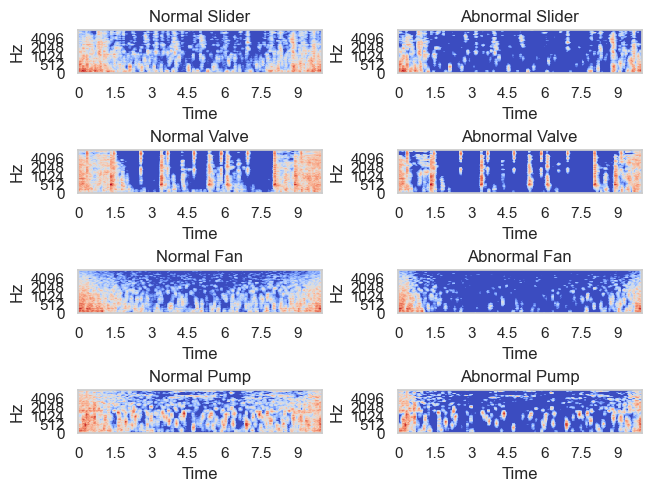

In [58]:
def plot_mel_spectrogram(*file_paths):
    rows = len(file_paths)
    fig, axes = plt.subplots(rows, 1, figsize=(8, 4), constrained_layout=True)

    # Handle single file case where axes might not be an array
    if rows == 1:
        axes = [axes]

    for i, file_path in enumerate(file_paths):
        print(f"Plotting: {file_path.name}")
        y, sr = librosa.load(file_path, sr=config.SAMPLING_RATE)

        # We don't necessarily need the strict scaler just to visualize the mel
        norm_mel = process_log_mel_spectrogram(y, sr=config.SAMPLING_RATE)

        axes[i].set_title(f"Mel Spectrogram: {file_path.name}")
        img = librosa.display.specshow(
            norm_mel, x_axis="time", y_axis="mel", sr=config.SAMPLING_RATE, ax=axes[i]
        )

    plt.colorbar(img, format="%+2.1f", ax=axes, location="right", shrink=0.8)
    plt.show()

def process_log_mel_spectrogram(y, sr, scaler_mel=None):
    mel_spectro = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=config.N_FFT,
        hop_length=config.HOP_LENGTH,
        n_mels=config.N_MELS,
    )
    log_mel_spectro = librosa.power_to_db(mel_spectro, ref=np.max)

    if log_mel_spectro.shape[1] > config.FIXED_WIDTH:
        log_mel_spectro = log_mel_spectro[:, : config.FIXED_WIDTH]
    else:
        log_mel_spectro = np.pad(
            log_mel_spectro,
            ((0, 0), (0, config.FIXED_WIDTH - log_mel_spectro.shape[1])),
        )

    if scaler_mel is None:
        scaler_mel = MinMaxScaler(feature_range=(0, 1))
        scaler_mel.fit(np.concatenate(mel_spectro).reshape(-1, 1))

    norm_mel = scaler_mel.transform(log_mel_spectro.flatten().reshape(-1, 1))
    return norm_mel.reshape(log_mel_spectro.shape)

fig, axes = plt.subplots(4, 2, constrained_layout=True)

MACHINE_TYPE = r"-6_dB_slider/slider/id_00/"
y1, sr1 = librosa.load(f"c:/dev/listen/raw_data/{MACHINE_TYPE}normal/00000000.wav", sr=SAMPLING_RATE)
y2, sr2 = librosa.load(f"c:/dev/listen/raw_data/{MACHINE_TYPE}abnormal/00000000.wav", sr=SAMPLING_RATE)
scaler_mel_path = f"c:/dev/listen/scalers/{MACHINE_TYPE}scaler_mel.pkl"
scaler_mel = joblib.load(scaler_mel_path) if os.path.exists(noise_path) else None
scaler_delta_path = f"c:/dev/listen/scalers/{MACHINE_TYPE}scaler_delta.pkl"
scaler_delta = joblib.load(scaler_delta_path) if os.path.exists(noise_path) else None
noise_path = f"c:/dev/listen/scalers/{MACHINE_TYPE}master_noise.pkl"
master_noise = joblib.load(noise_path) if os.path.exists(noise_path) else None

y1 = remove_background_noise(y1, sr1, master_noise)
y2 = remove_background_noise(y1, sr1, master_noise)

norm_mel = process_log_mel_spectrogram(y1, sr1, scaler_mel)
axes[0, 0].set_title('Normal Slider')
librosa.display.specshow(
            norm_mel, x_axis="time", y_axis="mel", sr=SAMPLING_RATE, ax=axes[0, 0]
        )
abnorm_mel = process_log_mel_spectrogram(y2, sr2, scaler_mel)
axes[0, 1].set_title("Abnormal Slider")
librosa.display.specshow(
    abnorm_mel, x_axis="time", y_axis="mel", sr=SAMPLING_RATE, ax=axes[0, 1]
)

MACHINE_TYPE = r"-6_dB_valve/valve/id_00/"
y1, sr1 = librosa.load(f"c:/dev/listen/raw_data/{MACHINE_TYPE}normal/00000000.wav", sr=SAMPLING_RATE)
y2, sr2 = librosa.load(f"c:/dev/listen/raw_data/{MACHINE_TYPE}abnormal/00000000.wav", sr=SAMPLING_RATE)
scaler_mel_path = f"c:/dev/listen/scalers/{MACHINE_TYPE}scaler_mel.pkl"
scaler_mel = joblib.load(scaler_mel_path) if os.path.exists(noise_path) else None
scaler_delta_path = f"c:/dev/listen/scalers/{MACHINE_TYPE}scaler_delta.pkl"
scaler_delta = joblib.load(scaler_delta_path) if os.path.exists(noise_path) else None
noise_path = f"c:/dev/listen/scalers/{MACHINE_TYPE}master_noise.pkl"
master_noise = joblib.load(noise_path) if os.path.exists(noise_path) else None

y1 = remove_background_noise(y1, sr1, master_noise)
y2 = remove_background_noise(y1, sr1, master_noise)

norm_mel = process_log_mel_spectrogram(y1, sr1, scaler_mel)
axes[1, 0].set_title('Normal Valve')
librosa.display.specshow(
            norm_mel, x_axis="time", y_axis="mel", sr=SAMPLING_RATE, ax=axes[1, 0]
        )
abnorm_mel = process_log_mel_spectrogram(y2, sr2, scaler_mel)
axes[1, 1].set_title("Abnormal Valve")
librosa.display.specshow(
    abnorm_mel, x_axis="time", y_axis="mel", sr=SAMPLING_RATE, ax=axes[1, 1]
)


MACHINE_TYPE = r"-6_dB_fan/fan/id_00/"
y1, sr1 = librosa.load(f"c:/dev/listen/raw_data/{MACHINE_TYPE}normal/00000000.wav", sr=SAMPLING_RATE)
y2, sr2 = librosa.load(f"c:/dev/listen/raw_data/{MACHINE_TYPE}abnormal/00000000.wav", sr=SAMPLING_RATE)
scaler_mel_path = f"c:/dev/listen/scalers/{MACHINE_TYPE}scaler_mel.pkl"
scaler_mel = joblib.load(scaler_mel_path) if os.path.exists(noise_path) else None
scaler_delta_path = f"c:/dev/listen/scalers/{MACHINE_TYPE}scaler_delta.pkl"
scaler_delta = joblib.load(scaler_delta_path) if os.path.exists(noise_path) else None
noise_path = f"c:/dev/listen/scalers/{MACHINE_TYPE}master_noise.pkl"
master_noise = joblib.load(noise_path) if os.path.exists(noise_path) else None

y1 = remove_background_noise(y1, sr1, master_noise)
y2 = remove_background_noise(y1, sr1, master_noise)

norm_mel = process_log_mel_spectrogram(y1, sr1, scaler_mel)
axes[2, 0].set_title('Normal Fan')
librosa.display.specshow(
            norm_mel, x_axis="time", y_axis="mel", sr=SAMPLING_RATE, ax=axes[2, 0]
        )
abnorm_mel = process_log_mel_spectrogram(y2, sr2, scaler_mel)
axes[2, 1].set_title("Abnormal Fan")
librosa.display.specshow(
    abnorm_mel, x_axis="time", y_axis="mel", sr=SAMPLING_RATE, ax=axes[2, 1]
)


MACHINE_TYPE = r"-6_dB_pump/pump/id_00/"
y1, sr1 = librosa.load(f"c:/dev/listen/raw_data/{MACHINE_TYPE}normal/00000000.wav", sr=SAMPLING_RATE)
y2, sr2 = librosa.load(f"c:/dev/listen/raw_data/{MACHINE_TYPE}abnormal/00000000.wav", sr=SAMPLING_RATE)
scaler_mel_path = f"c:/dev/listen/scalers/{MACHINE_TYPE}scaler_mel.pkl"
scaler_mel = joblib.load(scaler_mel_path) if os.path.exists(noise_path) else None
scaler_delta_path = f"c:/dev/listen/scalers/{MACHINE_TYPE}scaler_delta.pkl"
scaler_delta = joblib.load(scaler_delta_path) if os.path.exists(noise_path) else None
noise_path = f"c:/dev/listen/scalers/{MACHINE_TYPE}master_noise.pkl"
master_noise = joblib.load(noise_path) if os.path.exists(noise_path) else None

y1 = remove_background_noise(y1, sr1, master_noise)
y2 = remove_background_noise(y1, sr1, master_noise)

norm_mel = process_log_mel_spectrogram(y1, sr1, scaler_mel)
axes[3, 0].set_title('Normal Pump')
librosa.display.specshow(
            norm_mel, x_axis="time", y_axis="mel", sr=SAMPLING_RATE, ax=axes[3, 0]
        )
abnorm_mel = process_log_mel_spectrogram(y2, sr2, scaler_mel)
axes[3, 1].set_title("Abnormal Pump")
librosa.display.specshow(
    abnorm_mel, x_axis="time", y_axis="mel", sr=SAMPLING_RATE, ax=axes[3, 1]
)

plt.savefig("Mel Spectrogram - All Machine Types.png")
plt.show()